In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# Add the repository root to sys.path
repo_root = Path.cwd().resolve().parents[0]
if str(repo_root) not in sys.path:  sys.path.append(str(repo_root))

try:
    # import torch
    # import dataclasses
    # import torch.nn as nn
    # import torch.optim as optim
    # import numpy as np
    # import os
    # import wandb
    # from typing import List, Dict
    from moldiff.Dataset import PDBbind_Dataset
    # from torch_geometric.loader import DataLoader
    # from torch_geometric.data import Data
    # from datetime import datetime

    # # Import our molecular modules
    # from moldiff.molecular_diffusion import (
    #     MolecularDenoisingModel, 
    #     exponential_noise_schedule,
    #     log_uniform_sampling,
    #     edm_weighting,
    #     MolecularDiffusion, 
    #     remove_mean_batch
    # )
    from moldiff.metrics import (
        load_checkpoint,
        sample_molecules,
        sample_molecules_conditionally, 
        evaluate_atom_aa_distributions, 
        build_mol_objects
    )
    # from moldiff.egnn_dynamics import EGNNDynamics
    # import torch.nn.functional as F

    from main_optimize import (
        CONFIG,  
        create_batches_from_dataset
    )
    from moldiff.constants import (
        atom_decoder,
        atom_colors,
        aa_decoder3, 
        amino_acid_colors
    )
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    import networkx as nx
    import plotly.graph_objects as go
    from scipy.spatial.distance import cdist



    
except Exception as e:
    import traceback, sys
    print('Import failed:')
    print(e)
    traceback.print_exc()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
def visualize_ligand_pocket_graph(graph, 
                                  title="Ligand–Pocket Graph",
                                  atom_cutoff=1.9,
                                  contact_cutoff=4.0,
                                  show_edges=True,
                                  show_contacts=True,
                                  pocket_colors = False, 
                                  linewidth=2,
                                  markersize=6):
    """
    Visualize ligand–pocket 3D graph with colored atoms and residues (no axes).
    """

    # --- Decode atom and residue names ---
    def decode(one_hot, decoder):
        return [decoder[i] for i in one_hot.argmax(dim=1).tolist()]

    lig_coords = graph.ligand_coords.detach().cpu().numpy()
    lig_atoms  = decode(graph.ligand_features, atom_decoder)
    pocket_coords = graph.pocket_coords.detach().cpu().numpy()
    pocket_residues = decode(graph.pocket_features, aa_decoder3)

    # --- Ligand color & size arrays ---
    lig_colors = [atom_colors.get(atom, 'gray') for atom in lig_atoms]
    lig_size = [markersize for _ in lig_atoms]

    # --- Pocket color & size arrays ---
    # --- Pocket colors ---
    if pocket_colors:
        pocket_col = [amino_acid_colors.get(aa, 'lightgray') for aa in pocket_residues]
    else:
        pocket_col = ['lightgray' for _ in pocket_residues]
        
    pocket_size = [markersize * 0.8 for _ in pocket_residues]

    # --- Compute intra-ligand edges ---
    edge_traces = []
    if show_edges:
        dist_ll = cdist(lig_coords, lig_coords)
        edge_pairs = np.argwhere((dist_ll < atom_cutoff) & (dist_ll > 0))
        for i, j in edge_pairs:
            edge_traces.append(go.Scatter3d(
                x=[lig_coords[i,0], lig_coords[j,0], None],
                y=[lig_coords[i,1], lig_coords[j,1], None],
                z=[lig_coords[i,2], lig_coords[j,2], None],
                mode='lines',
                line=dict(color='gray', width=linewidth),
                hoverinfo='none',
                showlegend=False
            ))

    # --- Compute ligand-pocket contact edges ---
    if show_contacts:
        dist_lp = cdist(lig_coords, pocket_coords)
        contact_pairs = np.argwhere(dist_lp < contact_cutoff)
        for i, j in contact_pairs:
            edge_traces.append(go.Scatter3d(
                x=[lig_coords[i,0], pocket_coords[j,0], None],
                y=[lig_coords[i,1], pocket_coords[j,1], None],
                z=[lig_coords[i,2], pocket_coords[j,2], None],
                mode='lines',
                line=dict(color='lightblue', width=1, dash='dot'),
                hoverinfo='none',
                showlegend=False
            ))

    # --- Ligand nodes ---
    ligand_trace = go.Scatter3d(
        x=lig_coords[:,0], y=lig_coords[:,1], z=lig_coords[:,2],
        mode='markers+text',
        marker=dict(size=lig_size, color=lig_colors, line=dict(color='black', width=0.2)),
        text=lig_atoms, textposition='top center',
        hoverinfo='text',
        name='Ligand'
    )

    # --- Pocket nodes ---
    pocket_trace = go.Scatter3d(
        x=pocket_coords[:,0], y=pocket_coords[:,1], z=pocket_coords[:,2],
        mode='markers+text',
        marker=dict(size=pocket_size, color=pocket_colors, line=dict(color='black', width=0.1)),
        text=pocket_residues, textposition='top center',
        hoverinfo='text',
        name='Pocket'
    )

    # --- Axes off ---
    axis = dict(showbackground=False, showline=False, zeroline=False, 
                showgrid=False, showticklabels=False, title='')

    layout = go.Layout(
        title=title,
        width=1200, height=1200,
        showlegend=False,
        scene=dict(
            xaxis=dict(axis),
            yaxis=dict(axis),
            zaxis=dict(axis)
        ),
        margin=dict(t=100),
        hovermode='closest'
    )

    fig = go.Figure(data=edge_traces + [ligand_trace, pocket_trace], layout=layout)
    fig.show()

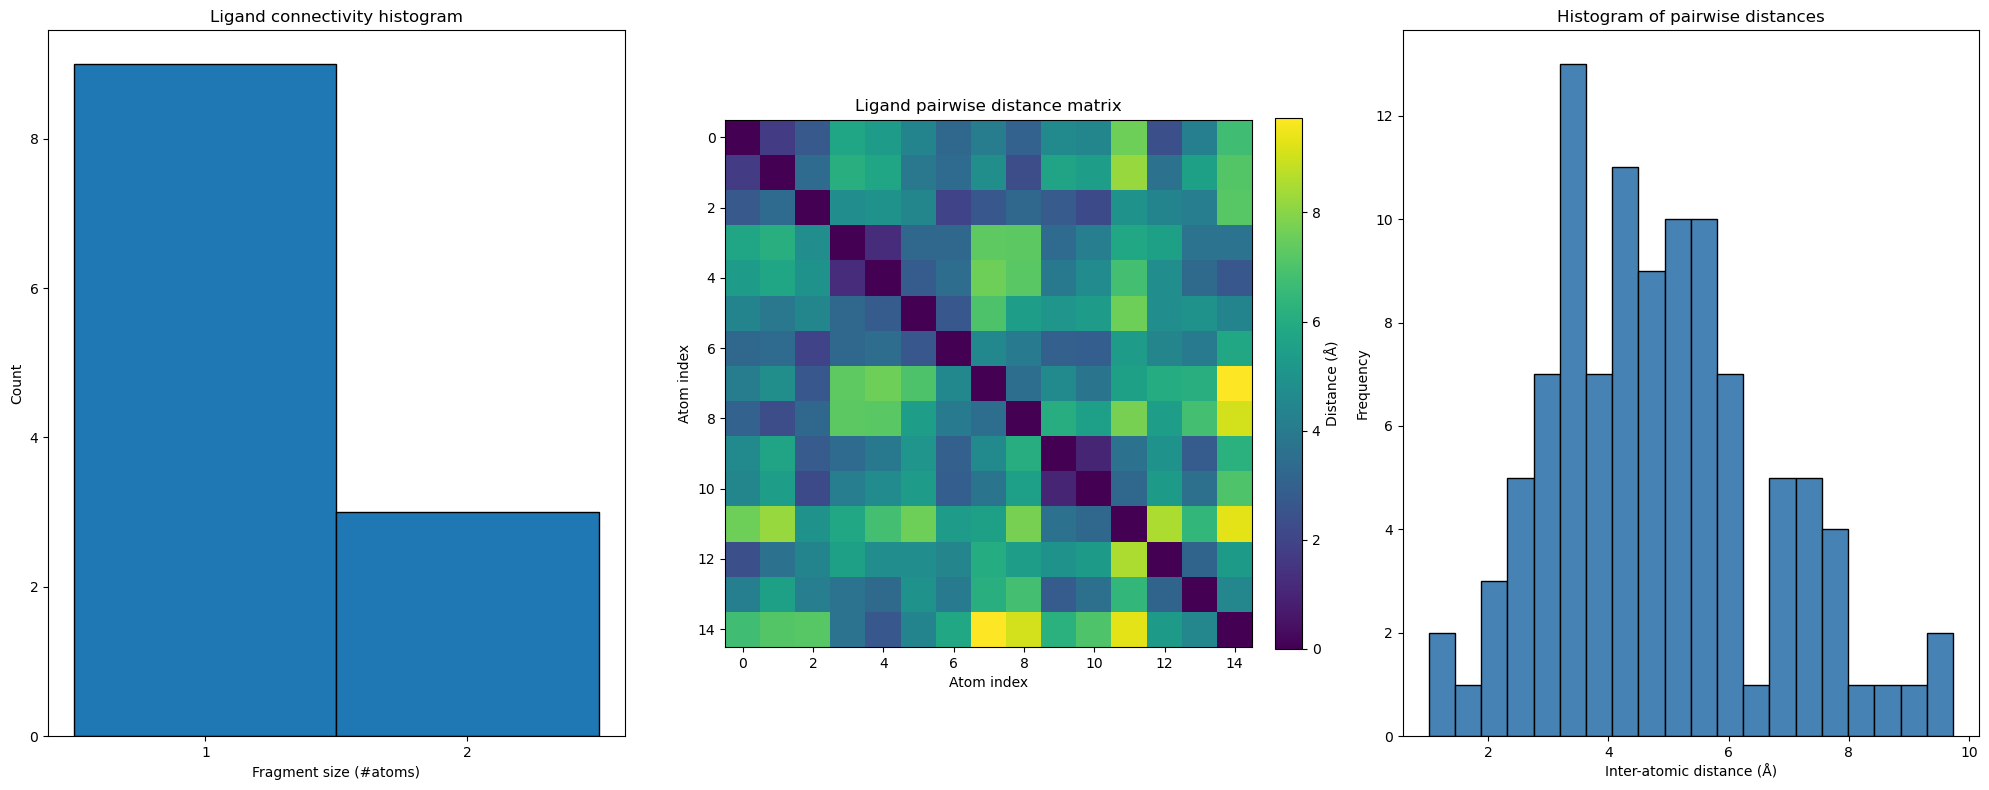

Number of fragments: 12
Fragment sizes: [2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1]


In [30]:
DATA_DIR = Path("../training_runs/1009_154726_datasets/dataset_pdbbind_train")
sample_i = 0
graph = torch.load(DATA_DIR / f"sample_{sample_i}.pt")


# --- PARAMETERS ---
atom_cutoff = 1.9      # cutoff for intra-ligand edges
contact_cutoff = 4.0   # cutoff for ligand-pocket contacts

# --- HELPERS ---
def build_adjacency(coords, cutoff=1.9):
    """Return adjacency matrix and pairwise distance matrix."""
    d = cdist(coords, coords)
    adj = (d < cutoff).astype(int)
    np.fill_diagonal(adj, 0)
    return adj, d

def decode_atoms(one_hot, decoder):
    idx = one_hot.argmax(dim=1)
    return [decoder[i] for i in idx]

# --- LIGAND DATA ---
lig_coords = graph.ligand_coords.detach().cpu().numpy()
lig_atoms  = decode_atoms(graph.ligand_features, atom_decoder)

# --- POCKET DATA ---
pocket_coords = graph.pocket_coords.detach().cpu().numpy()
pocket_residues = decode_atoms(graph.pocket_features, aa_decoder3)

# --- ADJACENCY & CONNECTIVITY ---
A, D = build_adjacency(lig_coords, cutoff=atom_cutoff)
G = nx.from_numpy_array(A)
components = [len(c) for c in nx.connected_components(G)]


import matplotlib.pyplot as plt
import numpy as np

# Create a row of 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# ============================================================
# 1️⃣ Fragment size histogram
# ============================================================
ax = axes[0]
ax.hist(components, bins=np.arange(1, max(components)+2)-0.5, edgecolor='k')
ax.set_xlabel("Fragment size (#atoms)")
ax.set_ylabel("Count")
ax.set_title("Ligand connectivity histogram")
ax.set_xticks(np.arange(1, max(components)+1))

# ============================================================
# 2️⃣ Pairwise distance heatmap
# ============================================================
ax = axes[1]
im = ax.imshow(D, cmap='viridis', interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Distance (Å)')
ax.set_title("Ligand pairwise distance matrix")
ax.set_xlabel("Atom index")
ax.set_ylabel("Atom index")

# ============================================================
# 3️⃣ Histogram of pairwise distances
# ============================================================
ax = axes[2]
# Take upper triangle (excluding zeros) to avoid duplicates/self-distances
distances = D[np.triu_indices_from(D, k=1)]
distances = distances[distances > 0]
ax.hist(distances, bins=20, color='steelblue', edgecolor='k')
ax.set_xlabel("Inter-atomic distance (Å)")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of pairwise distances")

plt.tight_layout()
plt.show()

print(f"Number of fragments: {len(components)}")
print(f"Fragment sizes: {components}")




In [28]:
visualize_ligand_pocket_graph(
    graph,
    title="Generated Ligand–Pocket Complex",
    atom_cutoff=1.9,
    contact_cutoff=4.0,
    show_edges=True,
    show_contacts=True
)